# MLP로 손글씨 숫자 인식하기 🔢
## Multi-Layer Perceptron (다층 퍼셉트론) 실습

**목표**: MNIST 손글씨 숫자 이미지(0~9)를 분류하는 신경망을 만들어봅니다.

**MNIST 데이터셋**
- 28×28 픽셀의 흑백 손글씨 숫자 이미지
- 총 60,000장의 학습 데이터 + 10,000장의 테스트 데이터
- 세계에서 가장 유명한 머신러닝 기초 데이터셋!

**MLP(다층 퍼셉트론)란?**
- 여러 개의 레이어(층)로 구성된 가장 기본적인 신경망
- 입력 → 은닉층 → 출력층 구조로 이루어져 있음

## 우리가 풀 문제가 뭔지 먼저 확인해봅시다!

아래 이미지들을 보면, 사람이 손으로 쓴 숫자들입니다.  
우리의 목표는 AI가 이 이미지를 보고 **0~9 중 어떤 숫자인지 맞추는 것**입니다.

사람 눈에는 쉽지만, 컴퓨터에게는 단순한 픽셀 숫자들의 배열일 뿐입니다.  
AI가 어떻게 이걸 학습하는지 지금부터 만들어봅시다!

In [ ]:
# 라이브러리 먼저 임시로 불러오기 (미리보기용)
import csv, numpy as np, matplotlib.pyplot as plt

# Colab 기본 제공 MNIST 데이터에서 몇 개만 읽기
preview_imgs, preview_labels = [], []
with open('./sample_data/mnist_test.csv') as f:
    for i, row in enumerate(csv.reader(f)):
        if i >= 20: break
        preview_imgs.append(np.array(row[1:], dtype=np.uint8).reshape(28, 28))
        preview_labels.append(int(row[0]))

# 시각화
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
fig.suptitle('MNIST handwritten digit data', fontsize=13)
for i, ax in enumerate(axes.flat):
    ax.imshow(preview_imgs[i], cmap='gray')
    ax.set_title(f'Label: {preview_labels[i]}', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import display, HTML

img = preview_imgs[0]

lines = []
for row in img:
    line = " ".join(f"{v:3d}" for v in row)
    lines.append(line)

text = "\n".join(lines)

display(HTML(f"""
<div style="
    font-family: monospace;
    white-space: pre;
    overflow-x: auto;
    border: 1px solid #ddd;
    padding: 12px;
    background-color: #f9f9f9;
    font-size: 13px;
    line-height: 1.3;
">
{text}
</div>
"""))

**🗺️ 우리가 앞으로 밟을 단계** — 아래 순서대로 차근차근 진행합니다.

<div align="center">
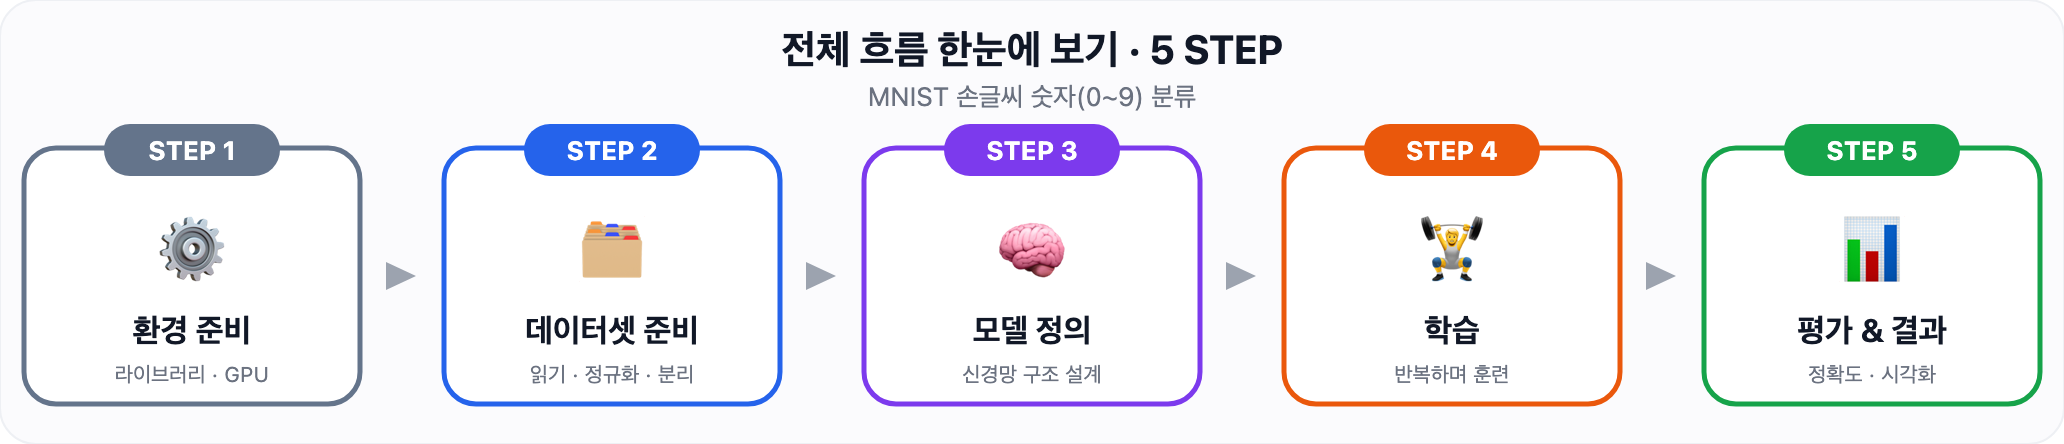
</div>

# ⚙️ STEP 1 · 환경 준비

본격적으로 시작하기 전에, 학습에 필요한 **도구(라이브러리)**를 불러오고 **계산 장치(GPU/CPU)**를 정합니다.

> **Colab GPU 활성화** (학습 속도 10배 이상!)
> 1. 상단 메뉴 → `런타임` → `런타임 유형 변경`
> 2. 하드웨어 가속기 → **T4 GPU** 선택 → 저장
>
> Colab에는 PyTorch·NumPy·Matplotlib이 이미 설치돼 있어 따로 설치할 필요가 없습니다.

### 1-1. 라이브러리 불러오기

실습에 사용할 라이브러리를 한 번에 불러옵니다. 버전이 출력되면 성공입니다.

In [ ]:
import csv
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

print('PyTorch 버전:', torch.__version__)

### 1-2. 학습 장치(GPU/CPU) 선택

GPU가 있으면 자동으로 사용합니다. GPU를 쓰면 훨씬 빠르게 학습할 수 있습니다.

In [ ]:
# GPU 사용 가능 여부 확인
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('현재 사용 장치:', device)
if device == 'cuda':
    print('GPU를 사용합니다! 빠르게 학습됩니다 🚀')
else:
    print('CPU를 사용합니다. 학습에 시간이 걸릴 수 있습니다.')

# 🗂️ STEP 2 · 데이터셋 준비

모델에게 먹일 데이터를 준비하는 단계입니다.
**데이터 읽기 → Dataset으로 감싸기 → DataLoader로 묶기** 순서로 진행합니다.

### 2-1. 데이터 읽기

MNIST 데이터는 Google Colab 기본 제공 샘플 데이터(CSV)를 사용합니다.

**CSV 파일 구조**
- 첫 번째 열: 라벨(0~9)
- 나머지 784개 열: 픽셀값(0~255) → 28×28로 변환

아래에서 경로를 설정하고, CSV를 읽어 28×28 배열로 만듭니다.

In [ ]:
# 학습/테스트 데이터 파일 경로
train_path = './sample_data/mnist_train_small.csv'
test_path  = './sample_data/mnist_test.csv'
img_size = 28  # MNIST 이미지 크기: 28×28 픽셀

In [ ]:
def mnist_reader(file_path, img_size=img_size):
    """CSV 파일에서 MNIST 이미지와 라벨을 읽어옵니다."""
    total_img   = []
    total_label = []

    with open(file_path) as csvfile:
        reader = csv.reader(csvfile)
        for row in reader:
            # 픽셀값을 28×28 배열로 변환
            img   = np.array(row[1:], dtype=np.uint8).reshape(img_size, img_size)
            label = int(row[0])  # 첫 번째 값이 정답 라벨
            total_img.append(img)
            total_label.append(label)

    return np.asarray(total_img), np.asarray(total_label)

In [ ]:
# 학습/테스트 데이터 로드
train_img, train_label = mnist_reader(train_path)
test_img,  test_label  = mnist_reader(test_path)

print(f"학습 데이터: {train_img.shape}  (이미지 수 × 높이 × 너비)")
print(f"테스트 데이터: {test_img.shape}")
print(f"라벨 예시: {train_label[:10]}")

In [ ]:
# 👀 확인: 픽셀값이 실제로 어떤 범위인가요?
print(f'픽셀값 범위: {train_img.min()} ~ {train_img.max()}  (0~255 정수)')
print()
print('첫 번째 이미지 픽셀 일부 (중앙 부근):')
print(train_img[0][10:15, 8:18])


### 2-2. Dataset 클래스 정의

PyTorch에서 데이터를 효율적으로 관리하기 위한 클래스입니다.
`__len__`은 데이터 총 개수, `__getitem__`은 인덱스로 하나씩 꺼내는 방법을 정의합니다. 여기서 픽셀값을 0~1로 정규화합니다.

In [ ]:
class MNIST_Dataset(Dataset):
    def __init__(self, img, label):
        self.img   = img
        self.label = label

    def __len__(self):
        # 전체 데이터 수 반환
        return len(self.img)

    def __getitem__(self, idx):
        sample = {}
        # 픽셀값을 0~1 범위로 정규화 (원래 0~255)
        sample['img']   = self.img[idx] / 255.0
        sample['label'] = self.label[idx]
        return sample

In [ ]:
# 👀 확인: Dataset이 데이터를 어떻게 변환하나요?
ds_temp = MNIST_Dataset(train_img, train_label)
print(f'데이터 수: {len(ds_temp)}장')  # __len__ 호출

before  = train_img[0]       # 원본 numpy (0~255)
after   = ds_temp[0]['img']  # Dataset 적용 후 (0.0~1.0)

# 이미지 중앙 일부(10×10) 픽셀값을 직접 비교
row, col = slice(12, 22), slice(9, 19)

print()
print('=== 정규화 전 (원본 픽셀값, 0~255 정수) ===')
print(before[row, col])
print()
print('=== 정규화 후 (픽셀값 ÷ 255, 0.0~1.0 실수) ===')
print(after[row, col].round(2))
print()
print('→ 값은 똑같지만 범위만 0~1로 축소됐습니다. 이미지 모양은 변하지 않아요!')


### 2-3. Train / Validation / Test 분리 & DataLoader

데이터를 세 가지로 나눕니다:

| 분류 | 역할 | 비유 |
|------|------|------|
| **Train** | 모델 학습 | 교과서로 공부 |
| **Validation** | 매 에폭마다 성능 확인, 하이퍼파라미터 조정 | 모의고사 |
| **Test** | 학습 완전히 끝난 후 최종 평가 딱 한 번 | 수능 |

> validation 없이 test로 매번 확인하면, 모르는 새 test에 맞춰 튜닝하게 됩니다.


#### 💡 잠깐, Overfitting(과적합)이란?

학습 데이터에만 너무 잘 맞게 학습되어, **새로운 데이터에는 성능이 떨어지는 현상**입니다.

```
정상적인 학습:   Train Loss ↓   Val Loss ↓   (같이 줄어듦)
Overfitting:    Train Loss ↓   Val Loss ↑   (train만 줄고 val은 올라감)
```

시험 문제를 통째로 외운 학생이 그 시험은 100점이지만, 비슷한 유형의 새 문제는 못 푸는 것과 같습니다.

**Validation set이 필요한 이유**: 학습 중 val loss가 올라가는 시점을 포착해서 overfitting을 감지할 수 있습니다.

**Dropout이 필요한 이유**: 학습할 때마다 뉴런을 랜덤으로 끄면 모델이 특정 패턴에만 의존하지 않고 더 일반적인 특징을 학습하게 됩니다 → overfitting 방지

In [ ]:
from torch.utils.data import random_split

batch_size = 64

# train 데이터의 80%는 학습, 20%는 validation으로 분리
full_train = MNIST_Dataset(train_img, train_label)
test_dataset = MNIST_Dataset(test_img, test_label)

val_size   = int(len(full_train) * 0.2)
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f'학습:      {len(train_dataset)}장')
print(f'Validation: {len(val_dataset)}장')
print(f'테스트:    {len(test_dataset)}장')
print()
print('학습 중 성능 확인 → validation,  최종 평가 → test')


In [ ]:
# 📊 그림: 데이터를 Train / Validation / Test 로 어떻게 나눴나?
import matplotlib.pyplot as plt

n_train, n_val, n_test = len(train_dataset), len(val_dataset), len(test_dataset)
n_full = n_train + n_val   # 학습용 = train + val

fig, ax = plt.subplots(figsize=(10, 2.6))
# 위 막대: 학습용 데이터를 8:2(train:val)로 분리
ax.barh(1, n_train, color='#2563eb', edgecolor='white')
ax.barh(1, n_val, left=n_train, color='#93c5fd', edgecolor='white')
# 아래 막대: 학습에 절대 쓰지 않고 따로 보관하는 test
ax.barh(0, n_test, color='#16a34a', edgecolor='white')

ax.text(n_train/2, 1, f'Train  {n_train:,}\n({n_train/n_full:.0%})', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold')
ax.text(n_train + n_val/2, 1, f'Val\n{n_val:,}', ha='center', va='center',
        color='#1e3a8a', fontsize=9, fontweight='bold')
ax.text(n_test/2, 0, f'Test  {n_test:,}', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold')

ax.set_yticks([0, 1])
ax.set_yticklabels(['Test set\n(= final exam)', 'Training set\n(= textbook + mock exam)'])
ax.set_xlabel('number of images')
ax.set_title('How the data is split   (Train : Val = 8 : 2,   Test kept completely separate)')
ax.set_xlim(0, max(n_full, n_test) * 1.05)
for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print(f'Train {n_train:,}  |  Val {n_val:,}  |  Test {n_test:,}')
print('Train=교과서로 공부  ·  Val=모의고사(중간 점검)  ·  Test=수능(맨 마지막 딱 한 번)')

In [ ]:
# 👀 확인: DataLoader가 데이터를 어떻게 묶나요?
batch = next(iter(train_dataloader))

print("=== DataLoader 배치 구조 ===")
print(f"이미지 shape: {batch['img'].shape}  → (배치크기, 높이, 너비)")
print(f"라벨  shape: {batch['label'].shape}  → (배치크기,)")
print()
print(f"라벨 예시: {batch['label'][:10].tolist()}")
print("→ 64개 이미지를 한 묶음으로 모델에 넣습니다.")

# 🧠 STEP 3 · 모델 정의

이제 신경망을 만듭니다. MLP는 이미지를 한 줄로 펼친(Flatten) 값을 입력받아 **784개 값 → 은닉층 → 10개 클래스 점수**를 출력합니다.

진행 순서: **입력 이해(Flatten) → 하이퍼파라미터 설정 → 모델 만들기**

> 🔧 표시가 붙은 단계는 값을 직접 바꿔보며 결과가 어떻게 달라지는지 실험해보세요!

**📐 모델 구조 한눈에 보기** — 입력부터 출력까지 데이터가 흐르는 모양입니다.

<div align="center">
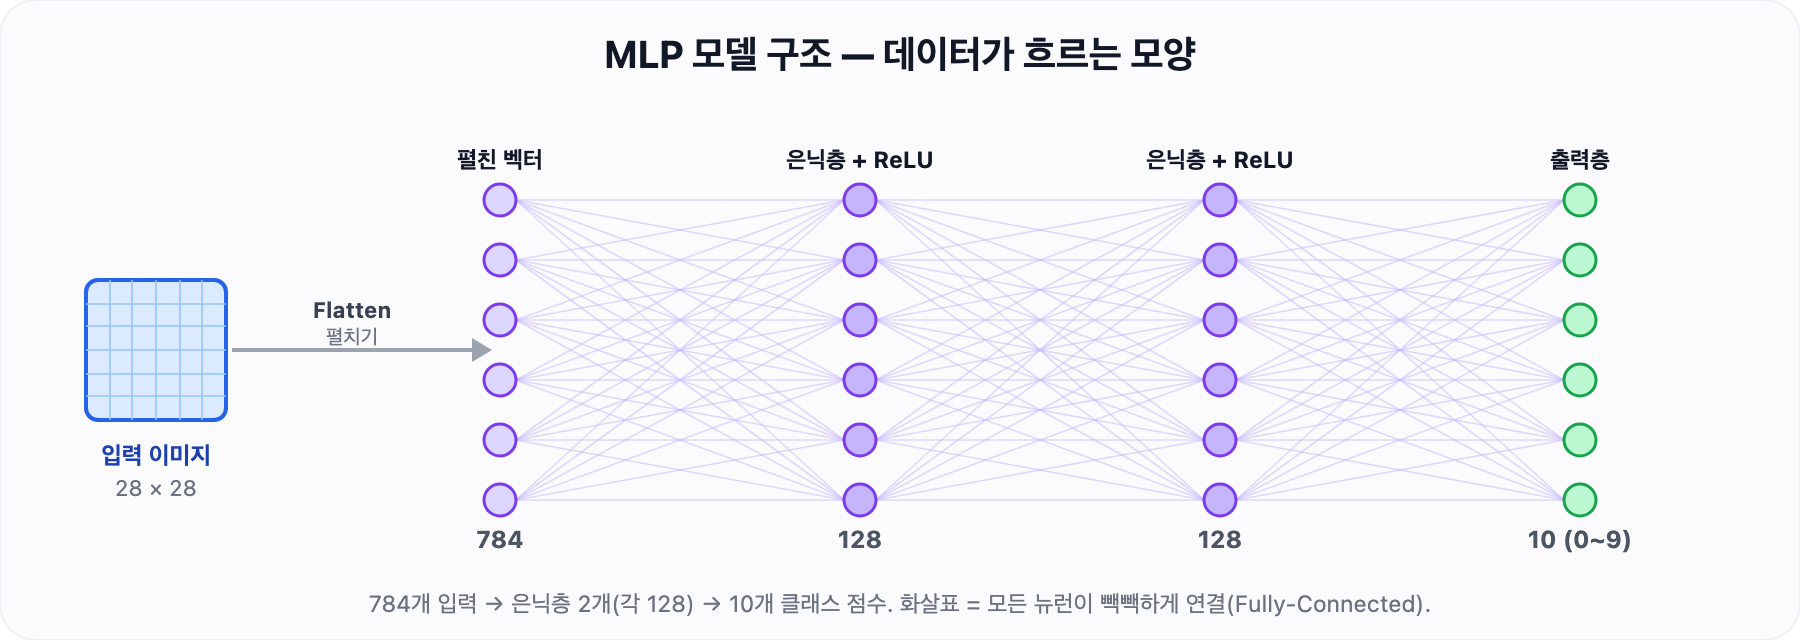
</div>

### 3-1. 입력 이해하기 (Flatten)

MLP는 1차원 입력만 받을 수 있습니다. 28×28 이미지를 784개짜리 한 줄로 펼치는 과정을 **Flatten**이라고 합니다.

In [ ]:
# 👀 확인: MLP에 들어가기 전, 이미지가 어떻게 펼쳐지나요?
sample_img = next(iter(test_dataloader))['img'][0]  # 28×28

print("=== Flatten 전후 비교 ===")
print(f"원본 shape: {sample_img.shape}  → 28×28 이미지")
flat = sample_img.view(-1)
print(f"Flatten 후: {flat.shape}  → 784개 숫자 한 줄")
print()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title('Original: 28×28', fontsize=11)
axes[0].axis('off')
axes[1].bar(range(len(flat)), flat.numpy(), color='steelblue', width=1.0)
axes[1].set_title('Flattened: 784 values (MLP input)', fontsize=11)
axes[1].set_xlabel('Pixel index')
axes[1].set_ylabel('Pixel value (0~1)')
plt.tight_layout()
plt.show()

### 3-2. 하이퍼파라미터 설정 🔧
아래 값들을 바꾼 뒤 이후 셀을 전부 다시 실행해보세요!

| 파라미터 | 현재 값 | 실험 아이디어 |
|----------|---------|--------------|
| `hidden_dim` | 128 | 64, 256, 512 로 바꾸면 어떻게 될까? |
| `learning_rate` | 1e-4 | 1e-3 (더 빠름) vs 1e-5 (더 느림) |
| `batch_size` | 64 | 32, 128 |
| `max_epoch` | 100 | 50 vs 200 |

In [ ]:
# ✏️ 여기서 하이퍼파라미터를 바꿔보세요!
hidden_dim    = 128   # 은닉층 크기: 클수록 표현력 ↑, 학습 느림
learning_rate = 1e-4  # 학습률: 클수록 빠르지만 불안정
batch_size    = 64    # 배치 크기
max_epoch     = 20    # 학습 횟수 (Colab GPU 기준 약 2분)

### 3-3. MLP 모델 만들기 🔧
아래 모델에는 은닉층이 2개입니다. **3번째 은닉층을 추가**해서 성능이 달라지는지 확인해보세요!

```python
# 힌트: block_3 을 추가하고 forward() 안에서 호출하세요
self.block_3 = nn.Sequential(
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
    nn.Dropout(0.5),
)
```

In [ ]:
class MLP(nn.Module):
    def __init__(self, dim_input=img_size**2, dim_hidden=hidden_dim, dim_output=10):
        super(MLP, self).__init__()

        self.block_1 = nn.Sequential(
            nn.Linear(dim_input, dim_hidden),
            nn.ReLU(),
            # nn.Dropout(0.3),   # ✏️ 나중에 주석 해제해보세요! (overfitting 방지)
        )
        self.block_2 = nn.Sequential(
            nn.Linear(dim_hidden, dim_hidden),
            nn.ReLU(),
            # nn.Dropout(0.3),   # ✏️ 나중에 주석 해제해보세요!
        )
        self.output_layer = nn.Linear(dim_hidden, dim_output)

    def forward(self, img):
        x = img.view(img.shape[0], -1)
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.output_layer(x)
        return x

model = MLP()  # hidden_dim은 위 하이퍼파라미터 셀의 값이 반영됩니다
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
print(model)


In [ ]:
# 👀 확인: 모델에 이미지를 넣으면 무엇이 나오나요?
sample_batch = next(iter(test_dataloader))
sample_img   = sample_batch['img'][:1].float().to(device)
true_label   = sample_batch['label'][0].item()

# 어떤 이미지인지 먼저 확인
plt.imshow(sample_batch['img'][0], cmap='gray')
plt.title(f'Input image  (true label: {true_label})')
plt.axis('off')
plt.show()

# 모델에 넣기
model = MLP()
model = model.to(device)
model.eval()
with torch.no_grad():
    output = model(sample_img)

print(f'입력 shape: {sample_img.shape}  →  출력 shape: {output.shape}')
print()
print('각 숫자(0~9)에 대한 점수:')
scores = output[0].cpu()
for i, val in enumerate(scores):
    bar    = '█' * int((val - scores.min()).item() * 15 / (scores.max() - scores.min()).item() + 1)
    marker = '  ← 예측!' if i == scores.argmax().item() else ''
    print(f'  숫자 {i}: {val:6.3f}  {bar}{marker}')
print()
print(f'정답: {true_label}  |  예측: {scores.argmax().item()}  (학습 전이라 아직 엉터리입니다!)')


# 🏋️ STEP 4 · 학습

준비한 데이터로 모델을 학습시킵니다. **학습/평가 함수를 정의 → 에폭을 돌며 학습**합니다.

**🔁 학습은 이 네 단계를 계속 반복하는 것** — 아래 그림이 `train()` 함수가 하는 일입니다.

<div align="center">
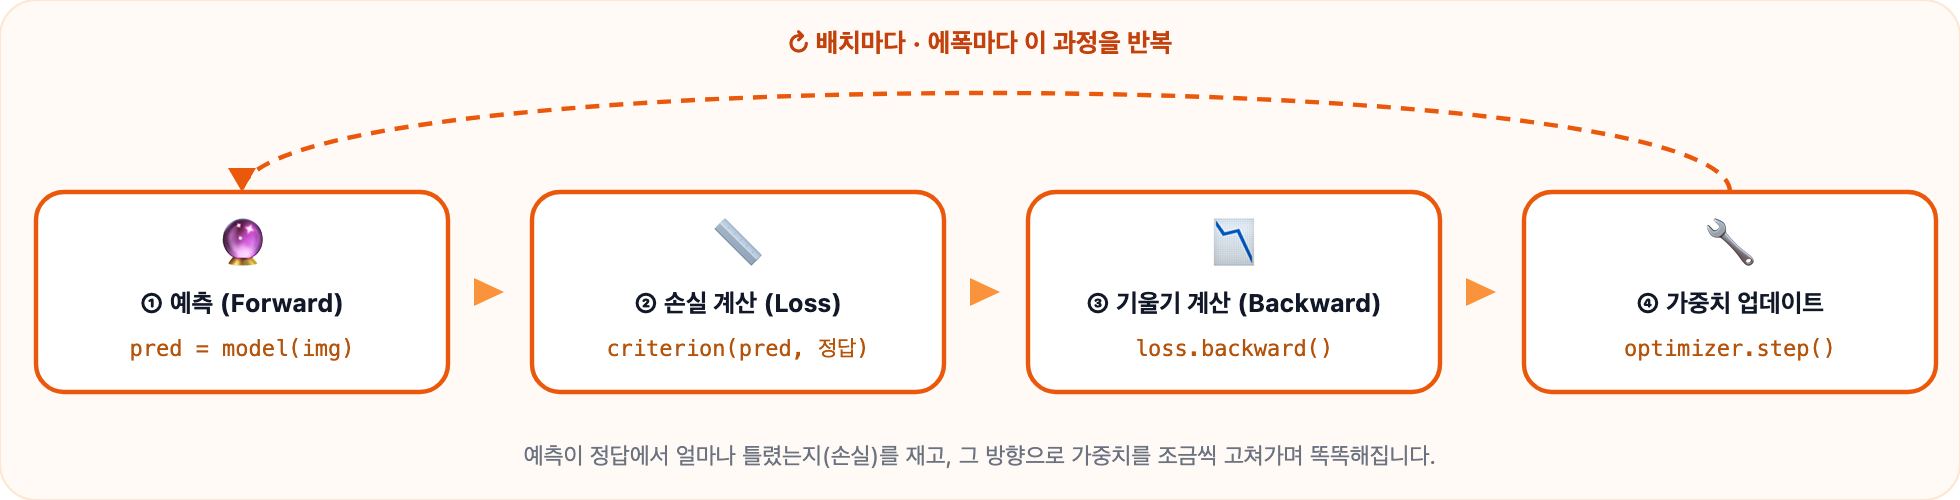
</div>

### 4-1. 학습 / 평가 함수 정의

**학습(train)**: 역전파로 가중치를 업데이트합니다.
**평가(evaluate)**: validation / test에 모두 사용하며, 가중치를 업데이트하지 않습니다.

In [ ]:
def train(model, optimizer, sample):
    model.train()  # 학습 모드 (Dropout 활성화)
    criterion = nn.CrossEntropyLoss()  # 분류 문제의 손실 함수

    img   = sample['img'].float().to(device)
    label = sample['label'].long().to(device)

    pred = model(img)  # 순전파 (forward pass)

    # 손실 계산: 모델 예측과 정답의 차이
    loss = criterion(pred, label)

    # 역전파: 손실을 줄이는 방향으로 가중치 업데이트
    optimizer.zero_grad()   # 이전 gradient 초기화
    loss.backward()         # gradient 계산
    optimizer.step()        # 가중치 업데이트

    # 정확도 계산: 예측값 중 가장 높은 클래스 선택
    num_correct = (torch.argmax(pred, dim=1) == label).sum().item()
    return loss.item(), num_correct

In [ ]:
def evaluate(model, sample):
    model.eval()  # 평가 모드 (Dropout 비활성화)
    criterion = nn.CrossEntropyLoss()

    img   = sample['img'].float().to(device)
    label = sample['label'].long().to(device)

    with torch.no_grad():  # gradient 계산 불필요 → 메모리/속도 절약
        pred = model(img)
        loss = criterion(pred, label)
        num_correct = (torch.argmax(pred, dim=1) == label).sum().item()

    return loss.item(), num_correct

### 4-2. 학습 실행

매 에폭(epoch)마다 전체 데이터를 한 번씩 학습하고, 검증(validation) 성능을 확인합니다. 학습이 끝나면 테스트로 딱 한 번 최종 평가합니다.

In [ ]:
# 매번 새로운 weight로 시작 (이전 학습 결과 초기화)
model     = MLP()
model     = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# batch_size 반영을 위해 DataLoader 재생성
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

max_epoch   = max_epoch
print_every = 5

tr_loss_history  = []
val_loss_history = []

for epoch in tqdm(range(max_epoch)):
    # ── 학습 ──────────────────────────
    train_loss, train_correct = 0.0, 0
    for sample in train_dataloader:
        loss, correct  = train(model, optimizer, sample)
        train_loss    += loss    / len(train_dataloader)
        train_correct += correct
    tr_loss_history.append(train_loss)
    torch.save(model.state_dict(), 'mlp_recent.pth')

    # ── Validation (매 에폭마다) ───────
    val_loss, val_correct = 0.0, 0
    for sample in val_dataloader:
        loss, correct  = evaluate(model, sample)
        val_loss      += loss    / len(val_dataloader)
        val_correct   += correct
    val_loss_history.append(val_loss)

    if (epoch + 1) % print_every == 0:
        train_acc = train_correct / len(train_dataset)
        val_acc   = val_correct   / len(val_dataset)
        print(f'[Epoch {epoch+1:3d}] '
              f'Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f} | '
              f'Train Acc: {train_acc:.1%} | Val Acc: {val_acc:.1%}')

# ── 최종 Test 평가 (딱 한 번) ────────
test_loss, test_correct = 0.0, 0
for sample in test_dataloader:
    loss, correct  = evaluate(model, sample)
    test_loss     += loss    / len(test_dataloader)
    test_correct  += correct
print(f'\n최종 Test Accuracy: {test_correct / len(test_dataset):.1%}')


# 📊 STEP 5 · 평가 & 결과

학습이 잘 됐는지 확인합니다. **학습 곡선으로 추세를 보고 → 실제 예측 결과**를 눈으로 확인합니다.

### 5-1. 학습 곡선 시각화

**그래프를 보는 법**:
- Train/Val Loss 모두 줄어든다 → 정상 학습 ✅
- Train Loss는 줄지만 Val Loss가 올라간다 → Overfitting ⚠️

Overfitting이 보이면? → Dropout 비율 높이기, 데이터 늘리기, 모델 크기 줄이기


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(tr_loss_history,  label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Overfitting 간단 진단
# val loss가 줄어들다 다시 올라가는지 확인 (후반부 추세)
if len(val_loss_history) >= 5:
    early_val = min(val_loss_history[:-3])       # 후반 3 에폭 이전 최솟값
    late_val  = min(val_loss_history[-3:])       # 후반 3 에폭 최솟값
    if late_val > early_val + 0.05:
        print(f'⚠️  Overfitting 의심! Val loss가 최저점({early_val:.3f}) 대비 다시 오르고 있습니다 ({late_val:.3f})')
        print('   → Dropout 비율을 높이거나, 모델을 단순하게 만들어보세요.')
    else:
        print(f'✅ 정상 학습 (Train: {tr_loss_history[-1]:.3f}, Val: {val_loss_history[-1]:.3f})')


### 5-2. 예측 결과 시각화

실제로 모델이 어떻게 예측하는지 확인해봅시다!

In [ ]:
sample = next(iter(test_dataloader))

model.eval()
with torch.no_grad():
    img        = sample['img'].float().to(device)
    gt_label   = sample['label']
    pred       = model(img)
    pred_label = torch.argmax(pred, dim=1).cpu()

num_show = min(10, sample['img'].shape[0])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flat

for i in range(num_show):
    ax = axes[i]

    image = sample['img'][i]
    if image.ndim == 3:
        image = image.squeeze(0)

    ax.imshow(image, cmap='gray')

    color = 'blue' if pred_label[i] == gt_label[i] else 'red'
    ax.set_title(f'GT: {gt_label[i].item()} / Pred: {pred_label[i].item()}', 
                 color=color, fontsize=10)
    ax.axis('off')

for j in range(num_show, 10):
    axes[j].axis('off')

plt.suptitle('Blue=Correct,  Red=Wrong', fontsize=12)
plt.tight_layout()
plt.show()